# Part A

In [9]:
!pip install visual-automata -q

In [10]:
from automata.fa.dfa import DFA
from visual_automata.fa.dfa import VisualDFA

In [11]:
dfa = {
    'states': {'q0', 'q1', 'qdead'},
    'input_symbols': set('abcdefghijklmnopqrstuvwxyz'),
    'transitions': {
        'q0': {letter: 'q1' for letter in 'abcdefghijklmnopqrstuvwxyz'},
        'q1': {letter: 'q1' for letter in 'abcdefghijklmnopqrstuvwxyz'},
        'qdead': {letter: 'qdead' for letter in 'abcdefghijklmnopqrstuvwxyz'}
    },
    'initial_state': 'q0',
    'accepting_states': {'q1'}
}

In [12]:
def check_word(word):
    current_state = 'q0'

    for char in word:
        if char not in 'abcdefghijklmnopqrstuvwxyz':
            current_state = 'qdead'
            break

        current_state = dfa['transitions'][current_state][char]

    if current_state in dfa['accepting_states']:
        return "Accepted"
    else:
        return "Not Accepted"

In [13]:
words = [
    "cat",
    "dog",
    "a",
    "zebra",
    "dog1",
    "1dog",
    "DogHouse",
    "Dog_house",
    " cats"
]

for word in words:
    print(word, "->", check_word(word))

cat -> Accepted
dog -> Accepted
a -> Accepted
zebra -> Accepted
dog1 -> Not Accepted
1dog -> Not Accepted
DogHouse -> Not Accepted
Dog_house -> Not Accepted
 cats -> Not Accepted


### Visualize

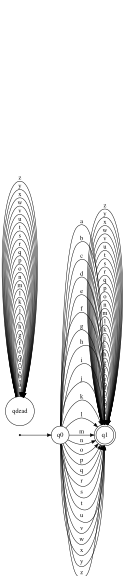

In [14]:
from visual_automata.fa.dfa import VisualDFA

visual_dfa = VisualDFA(
    states={'q0', 'q1', 'qdead'},
    input_symbols=set('abcdefghijklmnopqrstuvwxyz'),
    transitions={
        'q0': {letter: 'q1' for letter in 'abcdefghijklmnopqrstuvwxyz'},
        'q1': {letter: 'q1' for letter in 'abcdefghijklmnopqrstuvwxyz'},
        'qdead': {letter: 'qdead' for letter in 'abcdefghijklmnopqrstuvwxyz'}
    },
    initial_state='q0',
    final_states={'q1'}
)

# Visualize
visual_dfa.show_diagram()

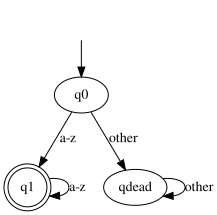

In [15]:
from graphviz import Digraph

dot = Digraph()

# States
dot.node('q0', 'q0')
dot.node('q1', 'q1', shape='doublecircle')
dot.node('qdead', 'qdead')

# Start arrow
dot.node('start', '', shape='none')
dot.edge('start', 'q0')

# Transitions
dot.edge('q0', 'q1', label='a-z')
dot.edge('q1', 'q1', label='a-z')
dot.edge('q0', 'qdead', label='other')
dot.edge('qdead', 'qdead', label='other')

# Display
dot

# Part 2

In [16]:
with open("brown_nouns.txt", "r") as file:
    corpus = [word.strip().lower() for word in file if word.strip()]

# Remove duplicates while preserving order
corpus = list(dict.fromkeys(corpus))

print("Number of words:", len(corpus))
print(corpus[:20])

Number of words: 17892
['investigation', 'primary', 'election', 'evidence', 'irregularities', 'place', 'jury', 'presentments', 'charge', 'praise', 'thanks', 'manner', 'term', 'reports', 'handful', 'interest', 'number', 'voters', 'size', 'city']


In [17]:
# (current_state, input) -> (next_state, output)
EPSILON = ""

transitions = {

    #normal chars
    ("q0", "letter"): ("qN", "SAME"),

    # deefault root
    ("qN", "letter"): ("qN", "SAME"),

    # last -y detect
    ("qN", "y"): ("qY", "y"),

    # s/z/x detect

    ("qN", "s"): ("qSZx", "s"),
    ("qN", "z"): ("qSZx", "z"),
    ("qN", "x"): ("qSZx", "x"),

    # detect sh/ch

    ("qN", "c"): ("qC", "c"),
    ("qN", "h"): ("qH", "h"),

    ("qC", "h"): ("qCH", "h"),

    ("qH", "h"): ("qH", "h"),

    # y - ies
    ("qY", "i"): ("qYI", EPSILON),
    ("qYI", "e"): ("qYIE", EPSILON),
    ("qYIE", "s"): ("qPL", EPSILON),

    # s, x, x
    ("qSZx", "e"): ("qE", EPSILON),
    ("qE", "s"): ("qPL", EPSILON),

    # -ch or -sh

    ("qCH", "e"): ("qCHE", EPSILON),
    ("qCHE", "s"): ("qPL", EPSILON),

    ("qSH", "e"): ("qSHE", EPSILON),
    ("qSHE", "s"): ("qPL", EPSILON),

    # default

    ("qN", "s"): ("qPL", EPSILON),
}

In [18]:
ALPHABET = set("abcdefghijklmnopqrstuvwxyz")

def get_symbol(char):
    return char if char in ALPHABET else None

In [19]:
expanded_transitions = {}

for (state, symbol), (next_state, output) in transitions.items():

    if symbol == "letter":
        for char in ALPHABET:
            expanded_transitions[(state, char)] = (next_state, char)

    else:
        expanded_transitions[(state, symbol)] = (next_state, output)

In [20]:
SINGULAR_STATES = {
    "qN",
    "qY",
    "qSZx",
    "qCH",
    "qSH"
}

PLURAL_STATE = "qPL"

In [21]:
def run_fst(word):
    state = "q0"
    output = []

    for char in word:

        transition = expanded_transitions.get((state, char))

        if transition is None:
            return "Invalid Word"

        next_state, out = transition

        if out != EPSILON:
            output.append(out)

        state = next_state
        # input ends

    if state in SINGULAR_STATES:
        return "".join(output) + "+N+SG"

    if state == PLURAL_STATE:
        return "".join(output) + "+N+PL"

    return "Invalid Word"

In [22]:
test_words = [
    "fox",
    "foxes",
    "watch",
    "watches",
    "try",
    "tries",
    "bag",
    "bags",
    "foxs"
]

for word in test_words:
    print(f"{word} = {run_fst(word)}")

fox = fox+N+SG
foxes = fox+N+PL
watch = watch+N+SG
watches = watch+N+PL
try = try+N+SG
tries = trie+N+PL
bag = bag+N+SG
bags = bag+N+PL
foxs = Invalid Word
